# Example on how to load data and analyse sub-grid variability and anomaly

By Lukas Brunner (lukas.brunner@uni-hamburg.de)

In [2]:
import os
import intake
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import healpix_functions as hf
from healpix_plot import get_listed_colormap, get_diverging_colormap, hp_plot, plot_polygon

## Navigating the intake catalog

In [3]:
cat = intake.open_catalog("https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")['online']
list(cat)

['ERA5',
 'IR_IMERG',
 'JRA3Q',
 'MERRA2',
 'casesm2_10km_nocumulus',
 'icon_d3hp003',
 'icon_d3hp003aug',
 'icon_d3hp003feb',
 'icon_ngc4008',
 'ifs_tco3999-ng5_deepoff',
 'ifs_tco3999-ng5_rcbmf',
 'ifs_tco3999-ng5_rcbmf_cf',
 'nicam_gl11',
 'scream-dkrz',
 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_glm_n1280_CoMA9_TBv1p2',
 'um_glm_n1280_GAL9',
 'um_glm_n2560_RAL3p3']

In [10]:
ds = cat['ifs_tco3999-ng5_rcbmf_cf'](zoom=11).to_dask()
ds

/fastdata/bm1235/python_environments/hamburg-hackathon/lib/python3.10/site-packages/xarray/core/dataset.py:282: UserWarning: The specified chunks separate the stored chunks along dimension "cell" starting at index 33554432. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/fastdata/bm1235/python_environments/hamburg-hackathon/lib/python3.10/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


<xarray.Dataset>
Dimensions:     (time: 10201, cell: 50331648, level_snow: 5, level: 25, crs: 1,
                 value: 50331648)
Coordinates:
  * crs         (crs) float32 nan
    lat         (cell) float32 dask.array<chunksize=(33554432,), meta=np.ndarray>
  * level       (level) float32 1.0 5.0 10.0 20.0 ... 925.0 950.0 975.0 1e+03
  * level_snow  (level_snow) float32 1.0 2.0 3.0 4.0 5.0
    lon         (cell) float32 dask.array<chunksize=(33554432,), meta=np.ndarray>
  * time        (time) datetime64[ns] 2020-01-01 ... 2021-03-01
Dimensions without coordinates: cell, value
Data variables: (12/81)
    100si       (time, cell) float32 dask.array<chunksize=(96, 262144), meta=np.ndarray>
    100u        (time, cell) float32 dask.array<chunksize=(96, 262144), meta=np.ndarray>
    100v        (time, cell) float32 dask.array<chunksize=(96, 262144), meta=np.ndarray>
    10si        (time, cell) float32 dask.array<chunksize=(96, 262144), meta=np.ndarray>
    2d          (time, cell) float32 dask.array<chunksize=(96, 262144), meta=np.ndarray>
    avg_sd24    (level_snow, cell) float32 dask.array<chunksize=(5, 6684672), meta=np.ndarray>
    ...          ...
    uas         (time, cell) float32 dask.array<chunksize=(96, 262144), meta=np.ndarray>
    va          (time, level, cell) float32 dask.array<chunksize=(24, 5, 65536), meta=np.ndarray>
    vas         (time, cell) float32 dask.array<chunksize=(96, 262144), meta=np.ndarray>
    wa          (time, level, cell) float32 dask.array<chunksize=(24, 5, 65536), meta=np.ndarray>
    z           (cell) float32 dask.array<chunksize=(33554432,), meta=np.ndarray>
    zg          (time, level, cell) float32 dask.array<chunksize=(24, 5, 65536), meta=np.ndarray>

## Subsetting the data and getting basic HEALPix information

In [11]:
date = '2020-01-01'
tas = ds['tas'].sel(time=date)
tas = tas.resample(time='1D').mean().squeeze()
tas.load()

<xarray.DataArray 'tas' (cell: 50331648)>
array([299.94186, 299.944  , 299.95328, ..., 299.66156, 299.6623 ,
       299.6613 ], dtype=float32)
Coordinates:
    lat      (cell) float32 0.01865 0.0373 0.0373 ... -0.0373 -0.0373 -0.01865
    lon      (cell) float32 45.0 45.02 44.98 45.0 ... 315.0 315.0 315.0 315.0
    time     datetime64[ns] 2020-01-01
Dimensions without coordinates: cell
Attributes: (12/15)
    paramId:                    167
    dataType:                   fc
    numberOfPoints:             50331648
    typeOfLevel:                heightAboveGround
    stepUnits:                  1
    stepType:                   instant
    ...                         ...
    name:                       2 metre temperature
    cfName:                     air_temperature
    cfVarName:                  t2m
    missingValue:               9999
    NV:                         0
    gridDefinitionDescription:  150

In [12]:
# zoom level from number of grid cells
hp.npix2order(tas.size)

11

In [13]:
# change zoom level
tas_z6 = hf.aggregate_grid_xr(tas, 6)
tas_z6

<xarray.DataArray 'tas' (cell: 49152)>
array([300.0578 , 300.07843, 300.43436, ..., 299.9197 , 299.19437,
       299.79092], dtype=float32)
Coordinates:
    time     datetime64[ns] 2020-01-01
Dimensions without coordinates: cell

## Simple mapplots

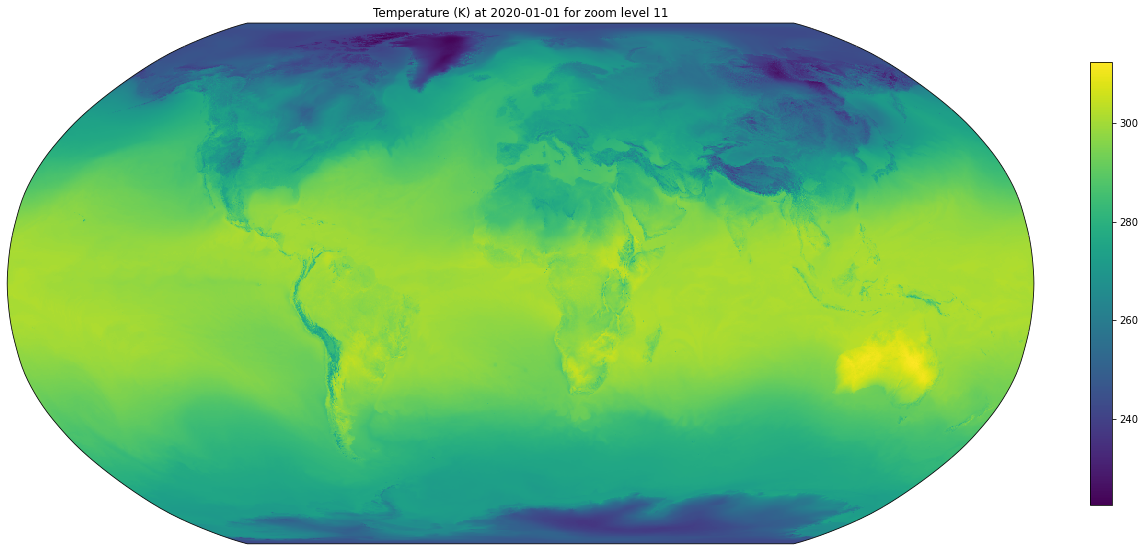

In [14]:
fig, ax, map_ = hp_plot(tas)
ax.set_title(f'Temperature (K) at {date} for zoom level 11');

In [10]:
# hp_plot(tas_z6)
# ax.set_title(f'Temperature (K) at {date} for zoom level 6');

## Calculating the subgrid variability

A measure of how much spatial variability is lost at coarser grids spacings compared to finer grid spacing.

In [15]:
tas_std = hf.aggregate_grid_xr(tas, z_out=6, method='std')

In [16]:
# hp_plot(tas_std, cmap='magma_r')
# ax.set_title(f'Temperature (K) subgrid variability at {date}: zoom level 11 -> 6');

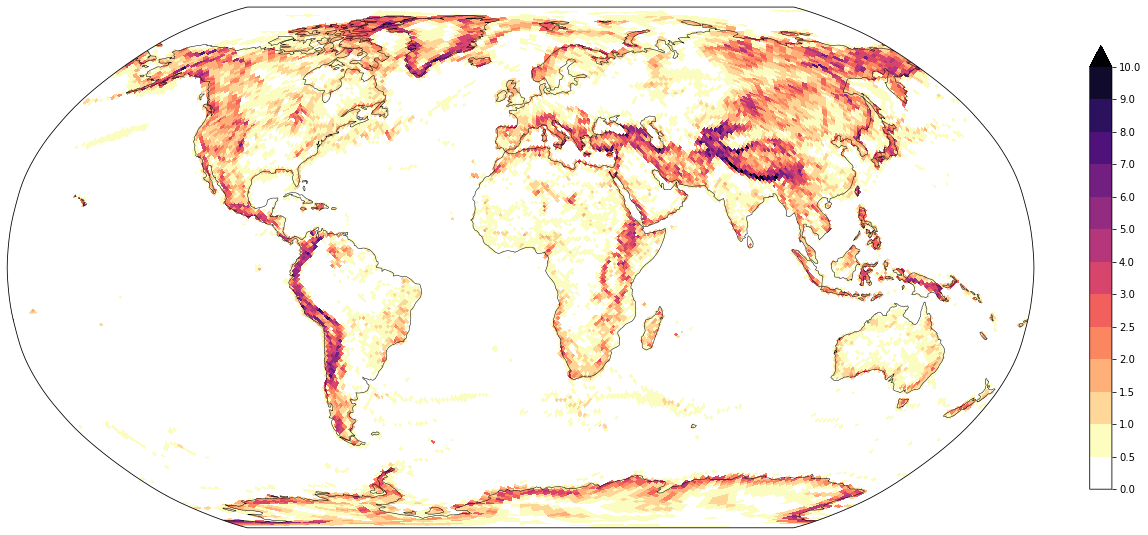

In [17]:
# customizing the plot

levels = [0, .5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 7, 8, 9, 10]
extend = 'max'
kwargs = dict(
    cmap=get_listed_colormap(levels, 'magma_r', return_colors=True, white='first', extend=extend),
    levels=levels, 
    extend=extend,
    add_coastlines=True,
)
hp_plot(tas_std, **kwargs)
ax.set_title(f'Temperature (K) subgrid variability at {date}: zoom level 11 -> 6');

## Calculating the subgrid anomaly

For each grid cell within a given coarser grid cell calculate the difference fine - coarse.

In [18]:
tas_anom = hf.subgrid_anomaly_xr(tas, z_coarse=6)

In [19]:
# levels = np.arange(-5, 5.1, .5)
# extend = 'both'
# kwargs = dict(
#     cmap=get_diverging_colormap(levels, return_colors=True, extend=extend),
#     levels=levels, 
#     extend=extend,
#     add_coastlines=True,
#     coastline_kwargs=dict(
#         color='k',
#         lw=.5,
#     ),
#     cbar_kwargs={'ticks': levels[::2]},
# )
# hp_plot(tas_anom, **kwargs)
# ax.set_title(f'Temperature (K) subgrid anomaly at {date}: zoom level 11 minus 6');

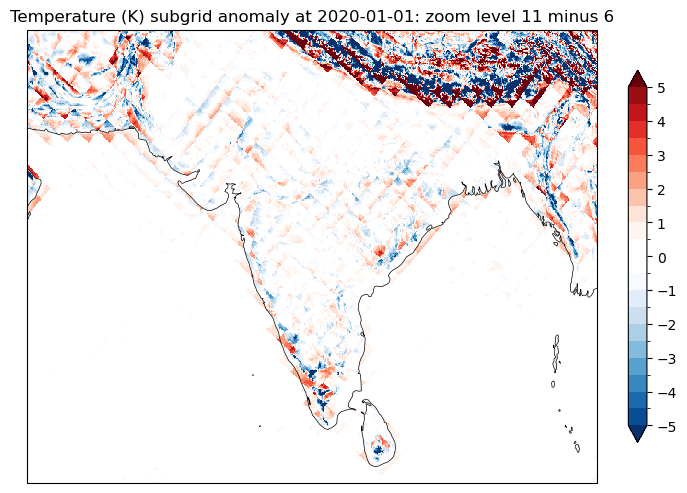

In [21]:
levels = np.arange(-5, 5.1, .5)
extend = 'both'
kwargs = dict(
    cmap=get_diverging_colormap(levels, return_colors=True, extend=extend),
    levels=levels, 
    extend=extend,
    add_coastlines=True,
    coastline_kwargs=dict(
        color='k',
        lw=.5,
    ),
    cbar_kwargs={'ticks': levels[::2]},
)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.Robinson()})
ax.set_extent([60, 95, 5, 30])
hp_plot(tas_anom, ax=ax, **kwargs)
ax.set_title(f'Temperature (K) subgrid anomaly at {date}: zoom level 11 minus 6');